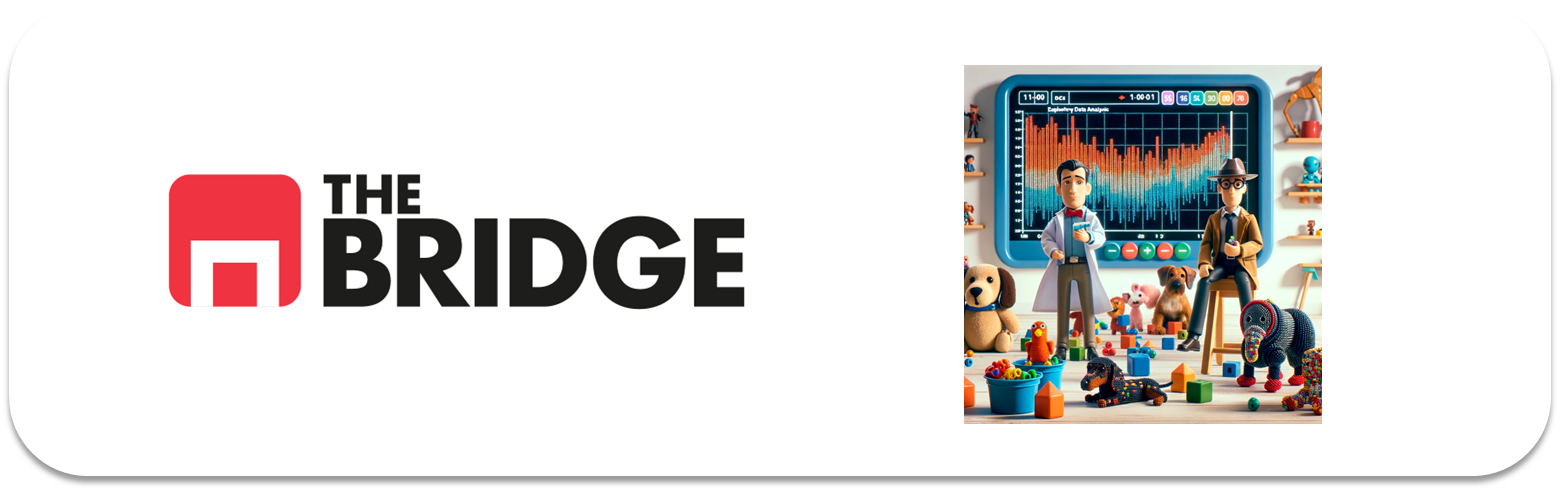

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [148]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bootcampviztools import pinta_distribucion_categoricas,\
plot_categorical_numerical_relationship, plot_categorical_relationship_fin,\
plot_grouped_histograms, grafico_dispersion_con_correlacion,\
plot_grouped_histograms


## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [98]:
df = pd.read_csv("./data/titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [99]:
df = df.drop(columns= ["deck", "survived", "pclass" , "embarked"])

### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [100]:
df["family_members"] = df["parch"] + df["sibsp"]

### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [101]:
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [102]:
df["age"] = df["age"].fillna(df.groupby(["who"])["age"].transform("mean"))

### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

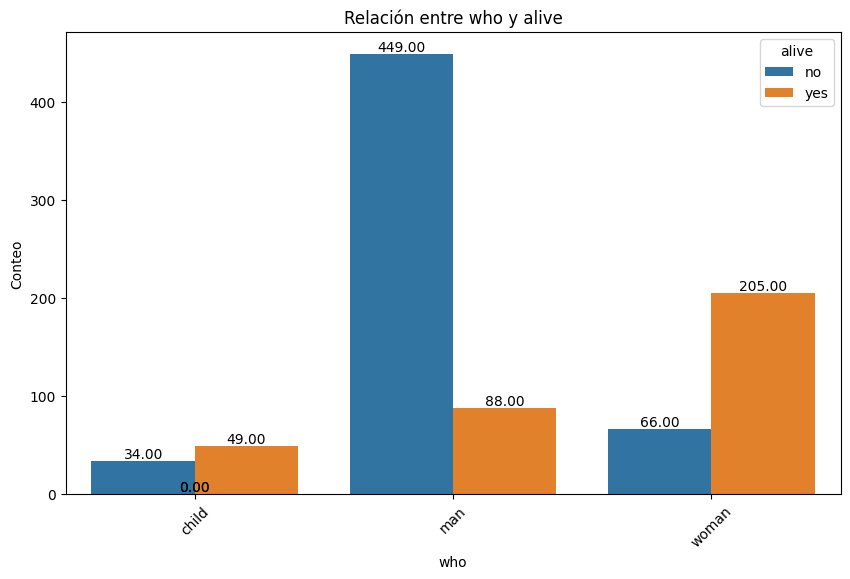

In [164]:
# 1- Columnas a analizar = Alive, who, sex

plot_categorical_relationship_fin(df,"who","alive",show_values= True)

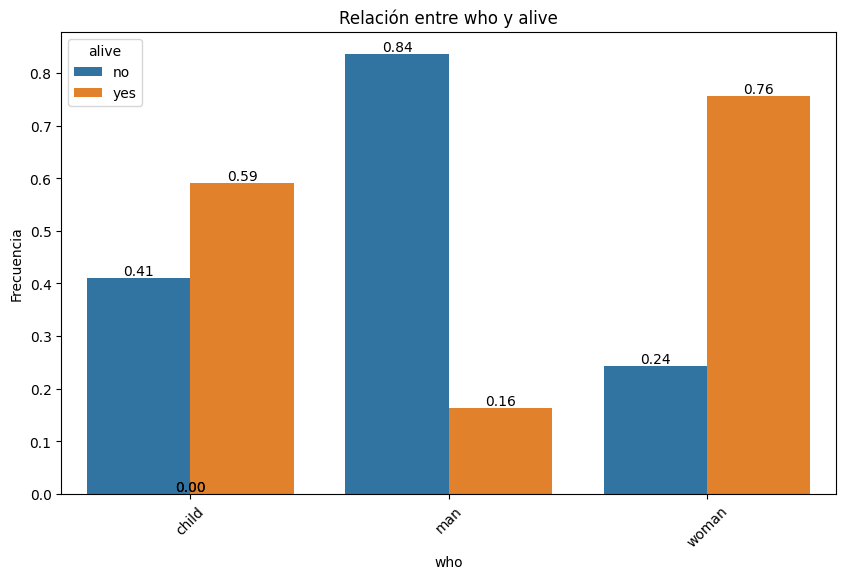

In [165]:
plot_categorical_relationship_fin(df,"who","alive", relative_freq = True,show_values= True)

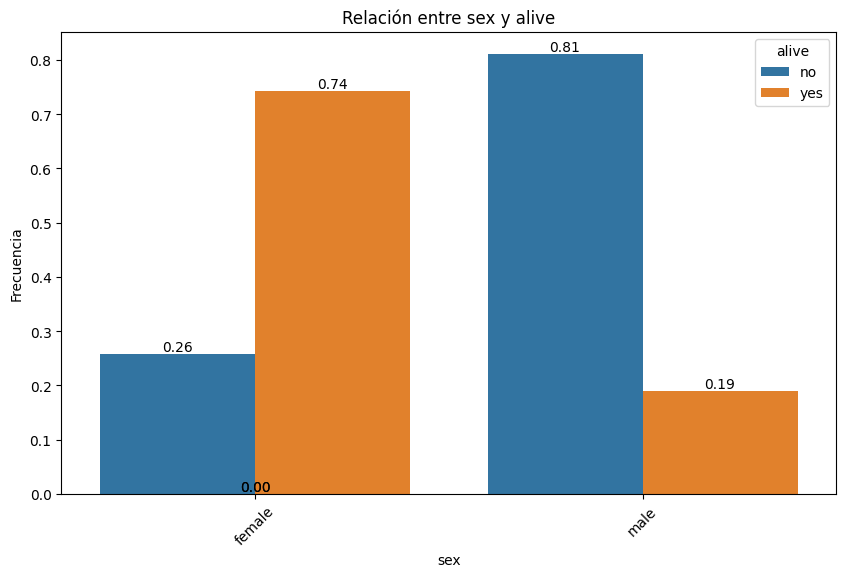

In [166]:
plot_categorical_relationship_fin(df,"sex","alive", relative_freq = True,show_values= True)

In [167]:
# Columnas
col_directora = "alive"
col_1 = "sex"
col_2 = "who"

# Diccionario donde guardaremos las particiones
diccionario_multivariante = {}

# Crea subconjuntos por alive (yes/no)
for valor in df[col_directora].unique():
    diccionario_multivariante[valor] = df.loc[df[col_directora] == valor, [col_1, col_2]]


Respuesta no:


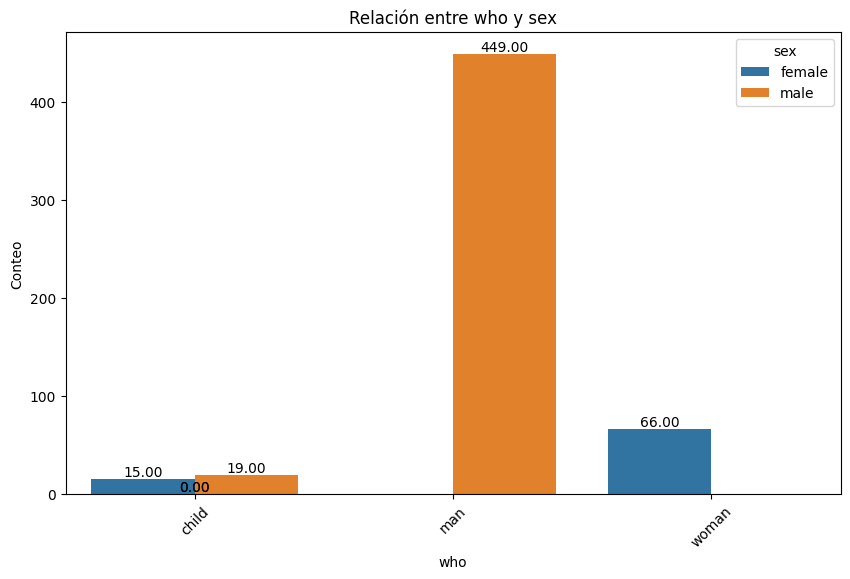

Respuesta yes:


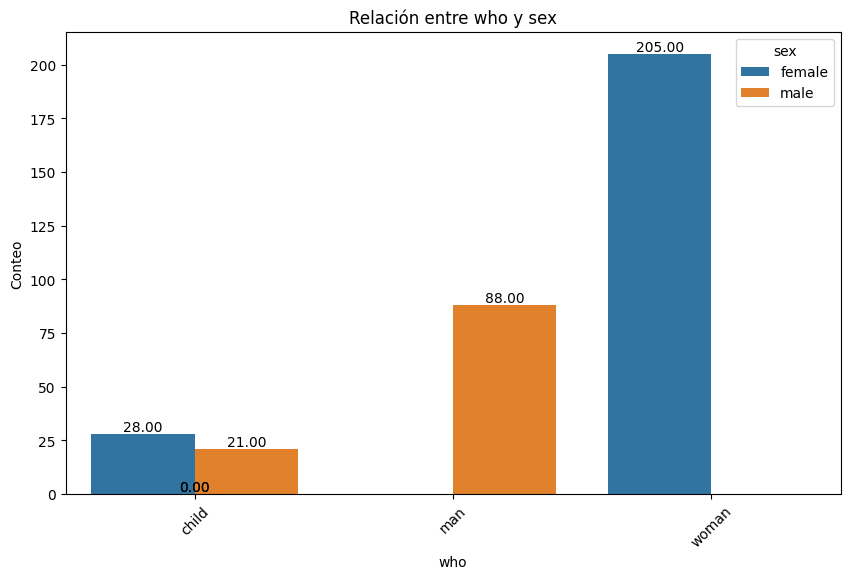

In [168]:
#VALOR ABSOLUTO
for valor, df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    plot_categorical_relationship_fin(df_datos, col_2, col_1, show_values=True)

Respuesta no:


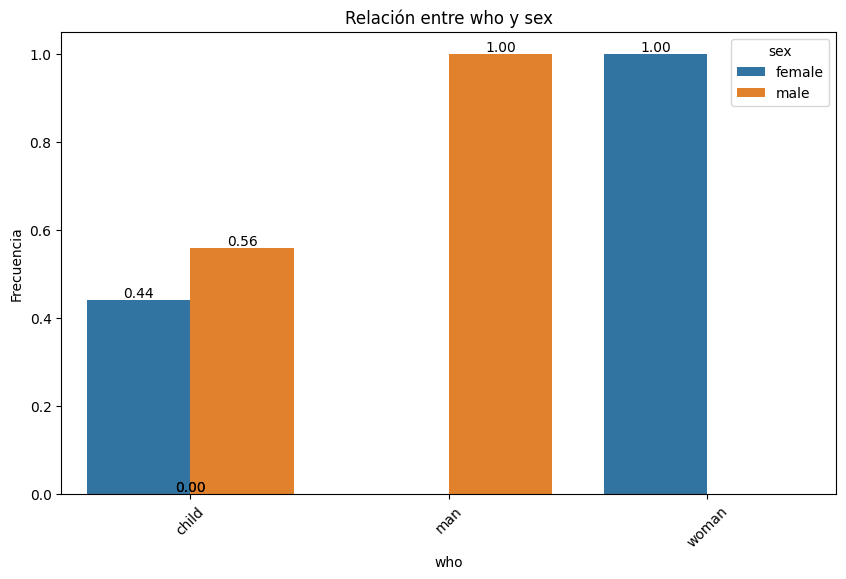

Respuesta yes:


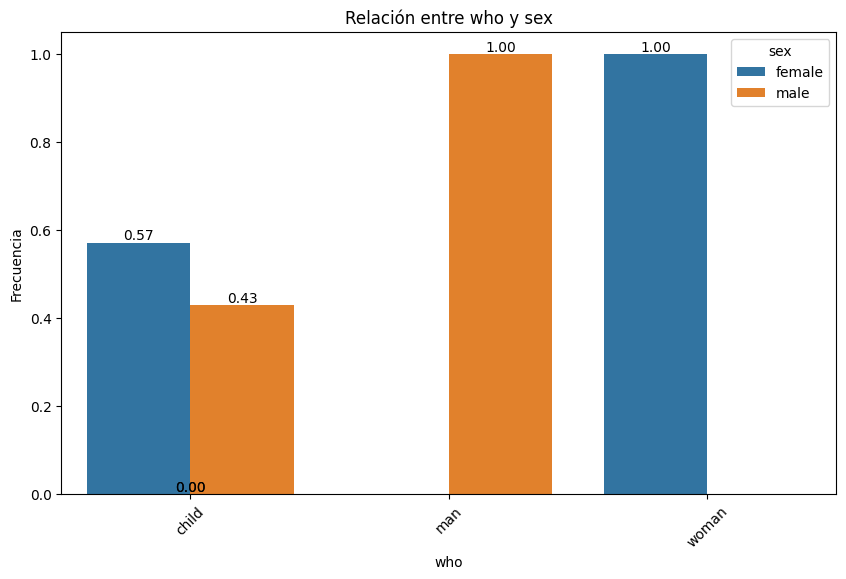

In [169]:
#VALOR RELATIVO
for valor, df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    plot_categorical_relationship_fin(df_datos, col_2, col_1,relative_freq = True, show_values=True)


In [170]:
tabla_contingencia = pd.crosstab(df['alive'], df['who'])
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)

Valor Chi-Cuadrado: 283.923050324233
P-Value: 2.2227620817798914e-62


**En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?**

En términos absolutos, las mujeres fueron quienes más sobrevivieron, seguidas por los niños. En términos relativos, las mujeres presentaron la mayor probabilidad de supervivencia (~ 76%), los niños una probabilidad intermedia (~ 59%) y los hombres adultos la más baja (~ 16%).  

Existe una relación estadísticamente significativa entre ser niño/mujer/hombre adulto y la probabilidad de sobrevivir. Los datos apoyan fuertemente el patrón histórico del Titanic, en el cual las mujeres y los niños tuvieron prioridad en el rescate. Esta conclusión se respalda tanto en los gráficos de distribución como en el test de independencia entre variables categóricas (Chi-cuadrado), cuyo p-value fue extremadamente bajo (p < 0.001), indicando dependencia clara entre las variables.

In [110]:
# 2 Columnas a analizar = Alive, class

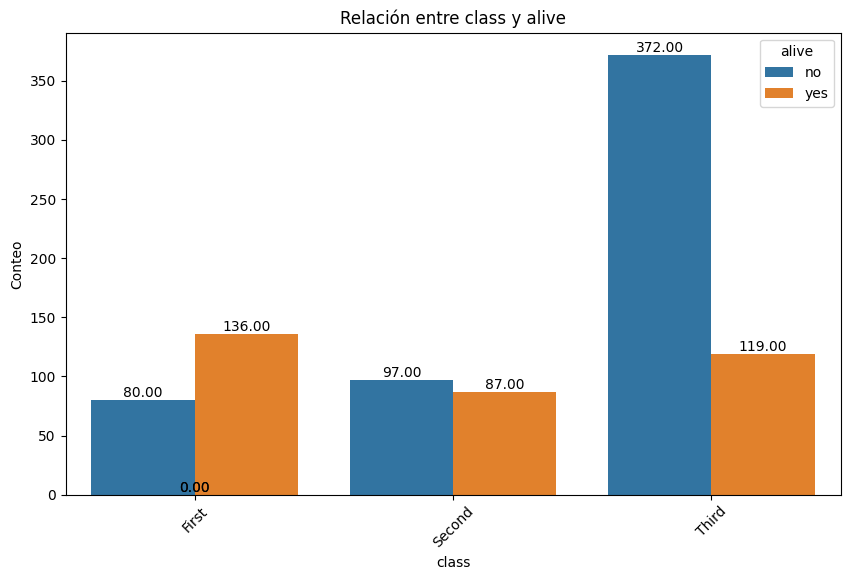

In [111]:
# En términos absolutos
plot_categorical_relationship_fin(df, "class", "alive", show_values= True)

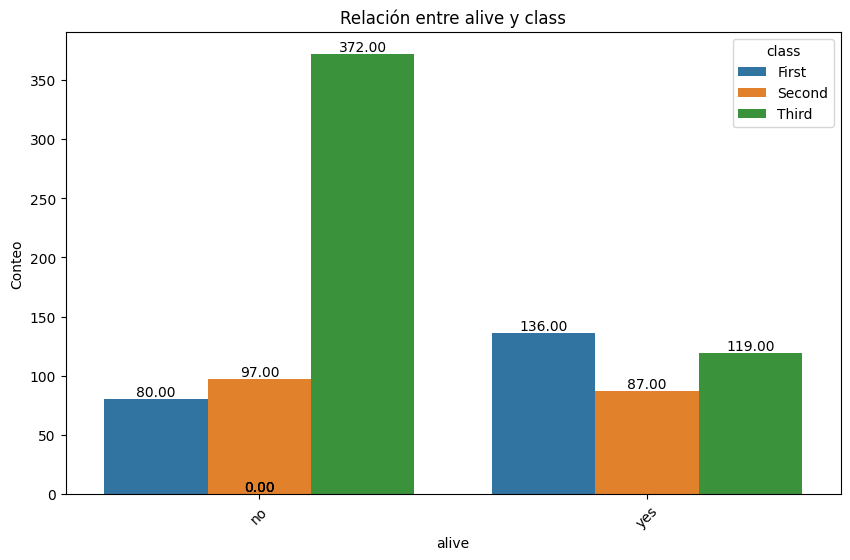

In [112]:
plot_categorical_relationship_fin(df, "alive", "class", show_values= True)

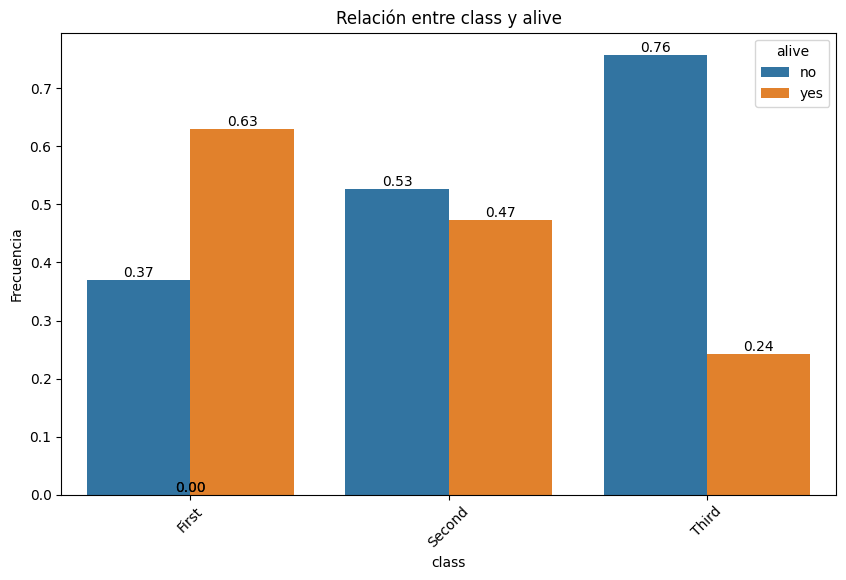

In [113]:
# En términos relativos
plot_categorical_relationship_fin(df, "class", "alive",relative_freq = True, show_values= True)

In [114]:
tabla_contingencia = pd.crosstab(df['class'],df['alive'])
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)


Valor Chi-Cuadrado: 102.88898875696056
P-Value: 4.549251711298793e-23


**En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? 
¿Existe alguna relación estadísticamente
significativa entre la clase en la que se viajaba y la supervivencia?**
En términos absolutos, el mayor número de supervivientes corresponde a los pasajeros de Primera clase, seguidos por los de Tercera clase y, en último lugar, los de Segunda clase. Sin embargo, esta comparación está influida tanto por la probabilidad real de supervivencia como por el tamaño de cada grupo; particularmente, la Tercera clase, al ser la más numerosa, concentra naturalmente más personas en todos los resultados.  

Cuando se analizan las proporciones relativas —es decir, la probabilidad de sobrevivir dentro de cada clase— la interpretación se vuelve más precisa. Allí se evidencia con claridad que pertenecer a Primera clase otorgaba la mayor probabilidad de supervivencia; en Segunda clase la distribución entre sobrevivientes y no sobrevivientes es prácticamente equilibrada; y en Tercera clase predominan ampliamente las muertes, reflejando la menor probabilidad de supervivencia del conjunto.  

En resumen, las diferencias que en los valores absolutos podrían atribuirse al tamaño de cada grupo quedan perfectamente aclaradas en el análisis proporcional: a mayor clase social, mayor era la probabilidad de sobrevivir.

In [115]:
# 3 Columnas a analizar = Alive, embark_town

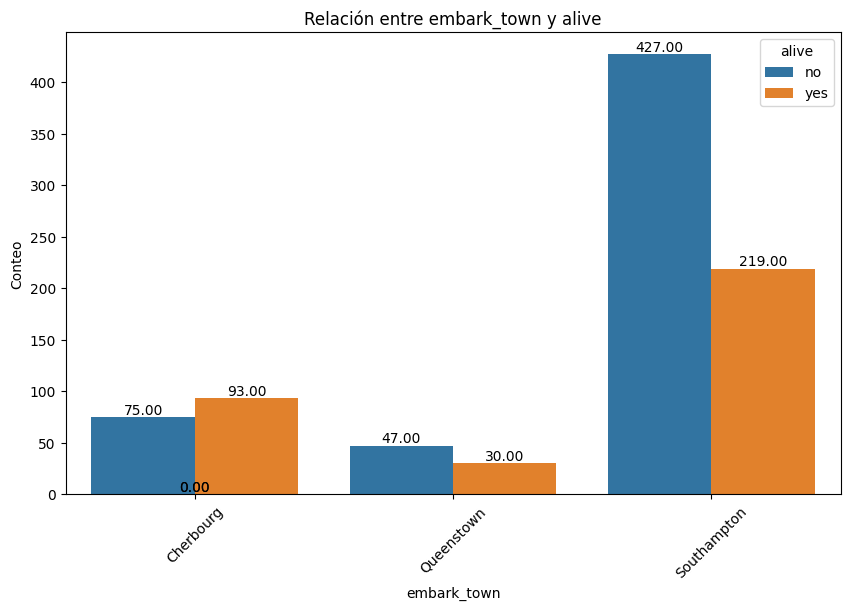

In [116]:
#En terminos absolutos
plot_categorical_relationship_fin(df, "embark_town", "alive", show_values= True)

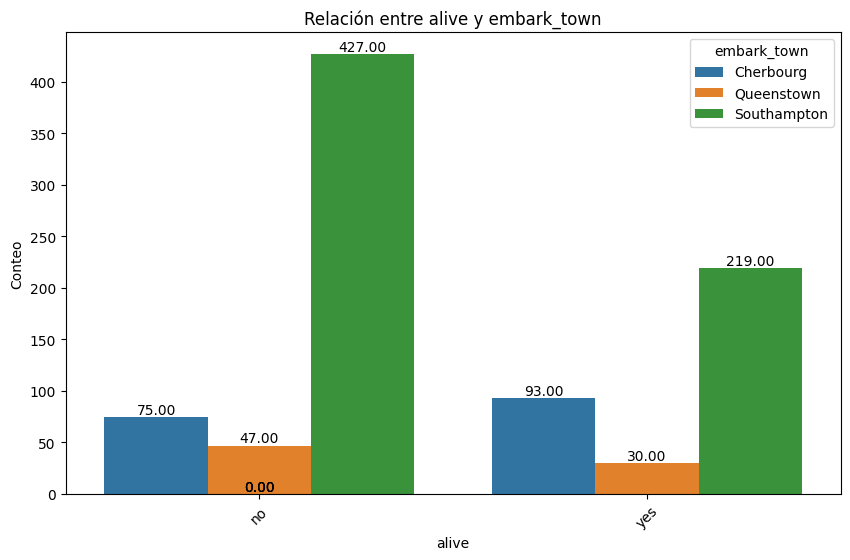

In [117]:
plot_categorical_relationship_fin(df,  "alive","embark_town", show_values= True)

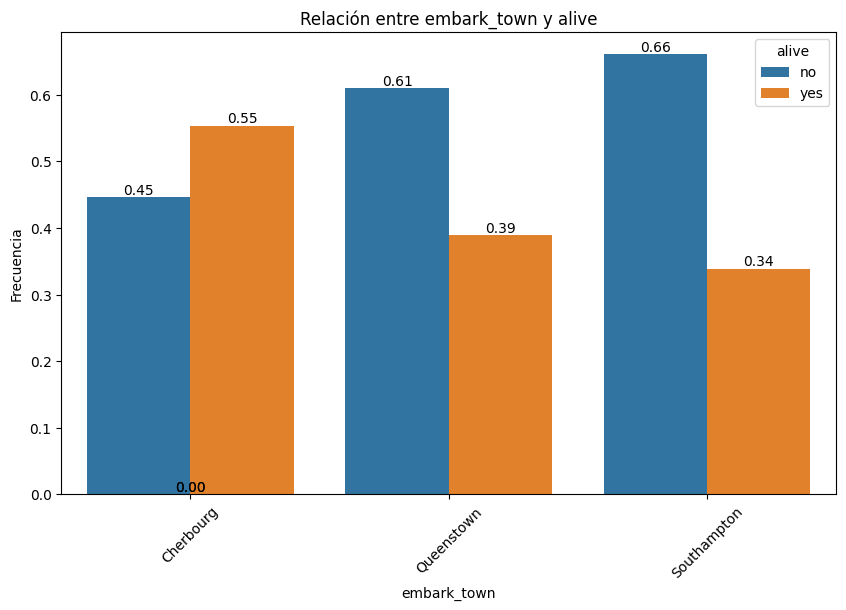

In [118]:
plot_categorical_relationship_fin(df, "embark_town", "alive",relative_freq = True, show_values= True)

In [119]:
tabla_contingencia = pd.crosstab(df["embark_town"],df["alive"])
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)


Valor Chi-Cuadrado: 25.964452881874784
P-Value: 2.3008626481449577e-06


**¿De qué ciudad sobrevivieron más personas ¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?**

Los pasajeros que embarcaron en Cherbourg tuvieron una mayor proporción de supervivencia, mientras que los de Southampton y Queenstown mostraron mayor proporción de fallecidos.
Estas diferencias porcentuales quedaron confirmadas como estadísticamente significativas mediante el test Chi-cuadrado.


In [120]:
# 4 Columnas a analizar = Alive, fare

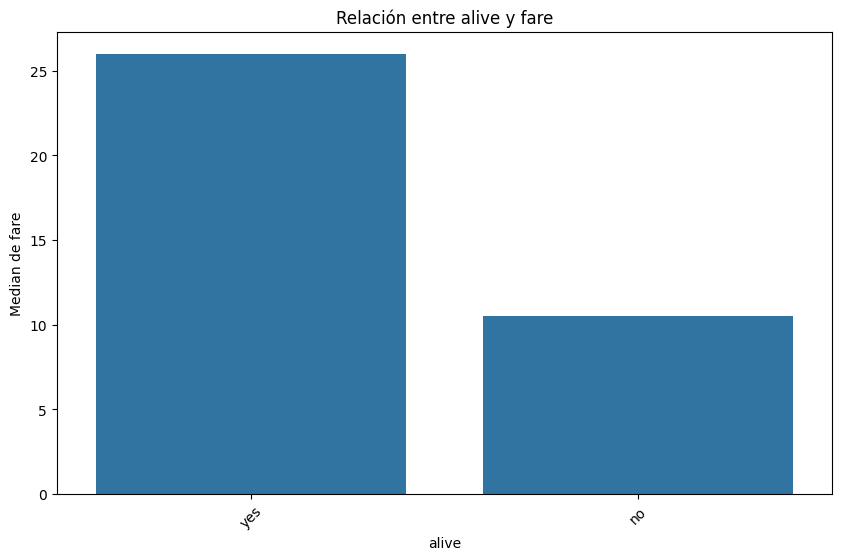

In [121]:
plot_categorical_numerical_relationship(df, "alive","fare", measure = "median")

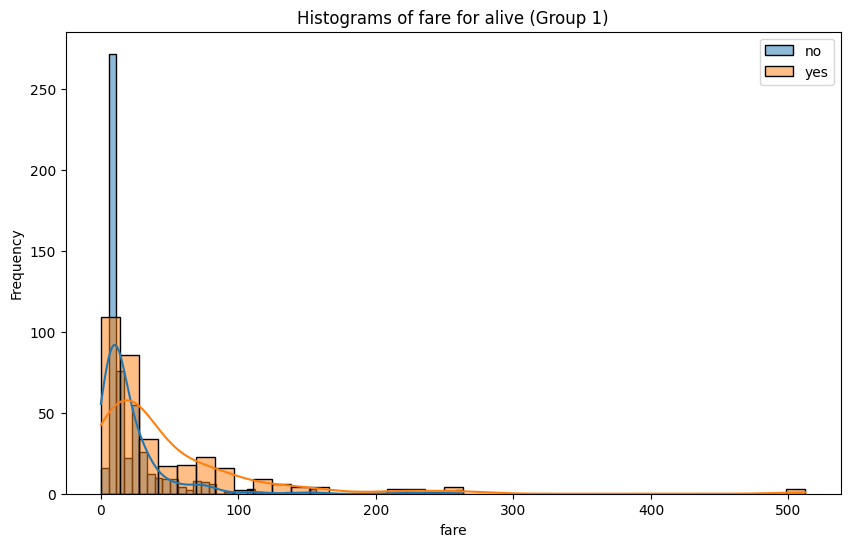

In [122]:
plot_grouped_histograms(df, "alive","fare",2)

In [123]:
tabla_contingencia = pd.crosstab(df["fare"],df["alive"])
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)


Valor Chi-Cuadrado: 425.8083805791106
P-Value: 1.1647635739939964e-11


**¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?**  
Hay una relación clara entre el precio del billete (fare) y la probabilidad de sobrevivir. Los pasajeros que pagaron tarifas más altas muestran mayor supervivencia, mientras que quienes pagaron tarifas bajas se agrupan en su mayoría entre los que no sobrevivieron.

In [130]:
# 5
df_ingreso_nulo = df[df["fare"] == 0]

In [132]:
df_ingreso_nulo.head()

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,family_members
179,male,36.000000,0,0,0.0,Third,man,True,Southampton,no,True,0
263,male,40.000000,0,0,0.0,First,man,True,Southampton,no,True,0
271,male,25.000000,0,0,0.0,Third,man,True,Southampton,yes,True,0
277,male,33.173123,0,0,0.0,Second,man,True,Southampton,no,True,0
302,male,19.000000,0,0,0.0,Third,man,True,Southampton,no,True,0


Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó? 
Pasajeros con tickets cortesía / acompañantes / niños pequeños
Algunos niños viajaban en tickets familiares donde el precio total del billete estaba asignado al adulto. En el dataset, a veces se registra el costo total para el grupo en una sola fila y las otras quedan en 0.

In [ ]:
# 6 Columnas a analizar = fare, alive, embark_town

In [155]:
col_directora = "alive"
col_1 = "fare"
col_2 = "embark_town"

# Diccionario donde guardaremos las particiones
diccionario_multivariante = {}

# Crea subconjuntos por alive (yes/no)
for valor in df[col_directora].unique():
    diccionario_multivariante[valor] = df.loc[df[col_directora] == valor, [ col_2,col_1]]

Respuesta no:


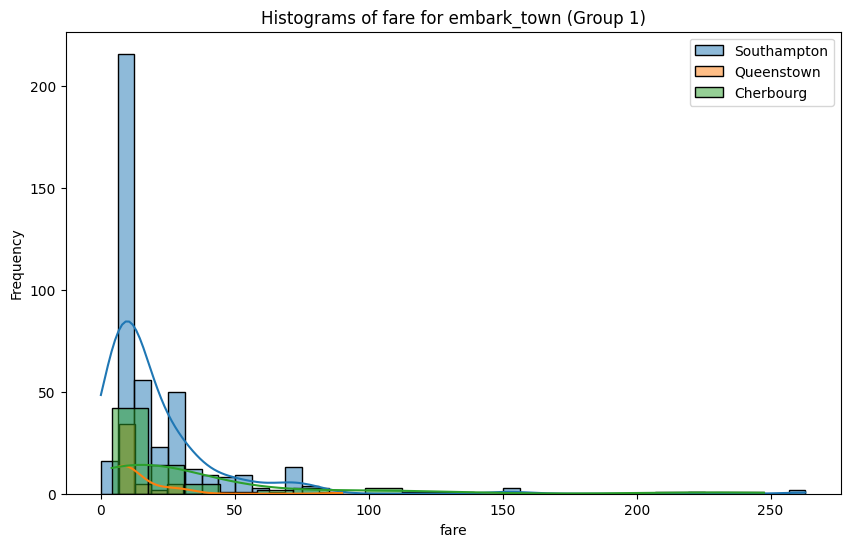

Respuesta yes:


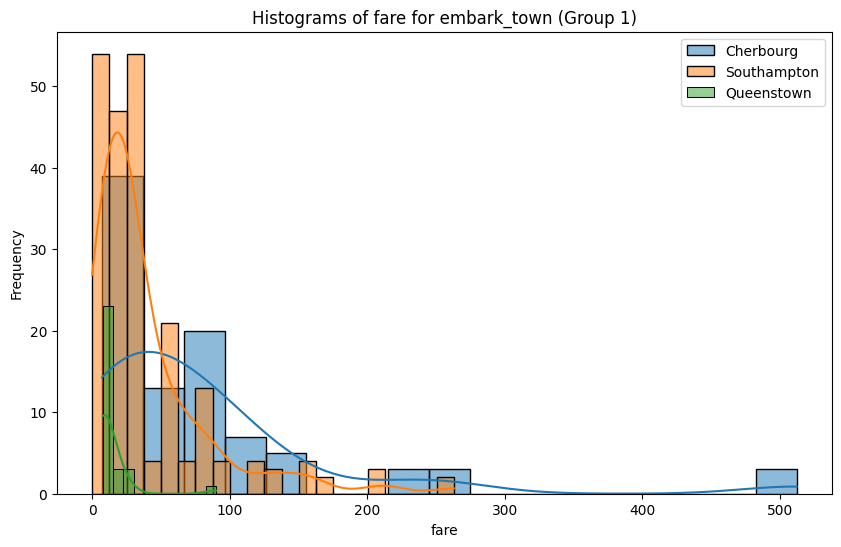

In [153]:
for valor,df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    plot_grouped_histograms(df_datos,col_2, col_1, 3)

In [154]:
df.groupby(["alive","embark_town"])["fare"].median()

alive  embark_town
no     Cherbourg      14.45830
       Queenstown      7.75000
       Southampton    10.50000
yes    Cherbourg      56.92920
       Queenstown      7.80835
       Southampton    26.00000
Name: fare, dtype: float64

**Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento.**  
La mediana del fare confirma el patrón observado previamente: los supervivientes pagaron tarifas más altas en promedio, especialmente los embarcados en Cherbourg. Southampton muestra valores intermedios y Queenstown valores consistentemente bajos. Esto sugiere que el precio del billete —y, por extensión, la clase social— estuvo estrechamente asociado a la probabilidad de supervivencia.

In [ ]:
#7 Columnas a analizar = alive, class, age

In [156]:
col_directora = "alive"
col_1 = "age"
col_2 = "class"

# Diccionario donde guardaremos las particiones
diccionario_multivariante = {}

# Crea subconjuntos por alive (yes/no)
for valor in df[col_directora].unique():
    diccionario_multivariante[valor] = df.loc[df[col_directora] == valor, [ col_2,col_1]]

Respuesta no:


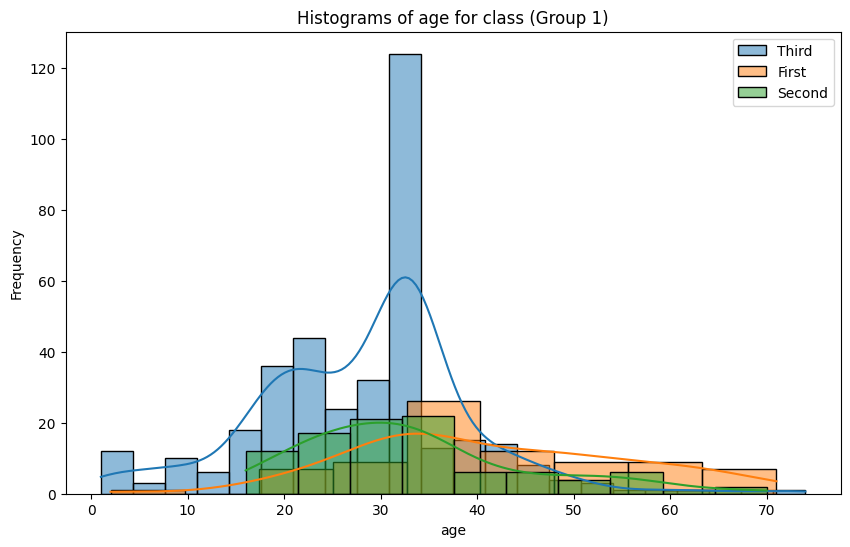

Respuesta yes:


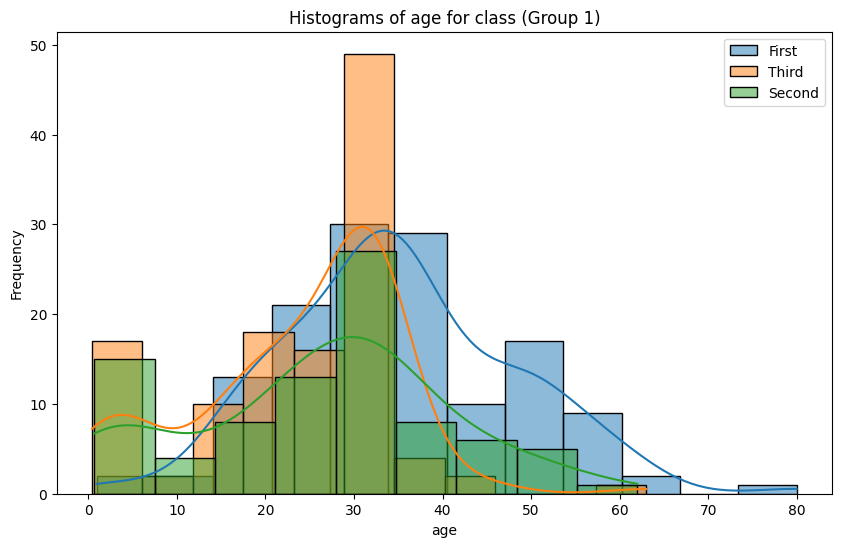

In [157]:
for valor,df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    plot_grouped_histograms(df_datos,col_2, col_1, 3)

**Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?**

Al analizar conjuntamente la clase en la que viajaban los pasajeros, su edad y la probabilidad de sobrevivir, se observa un patrón muy definido: la primera clase concentra la mayor supervivencia, predominando allí adultos jóvenes y de mediana edad que lograron salvarse con mayor frecuencia.En contraste, la tercera clase reúne la mayor cantidad de fallecidos, sobre todo adultos entre 15 y 35 años, mientras que los pocos supervivientes de esta clase se concentran mayoritariamente en edades más bajas, lo que coincide con la prioridad histórica dada a “mujeres y niños”.  
La segunda clase muestra un comportamiento intermedio, con una distribución de edades más homogénea y una supervivencia cercana al 50%. En conjunto, la agrupación que claramente muestra mayor ventaja es adultos jóvenes de primera clase, mientras que el grupo con peor pronóstico fueron los adultos de tercera clase, independientemente de su edad específica. Este análisis confirma una fuerte interacción entre clase social y edad en la probabilidad de sobrevivir al Titanic.


In [158]:
#8 Columnas a analizar = alive, fare, age

In [161]:
col_directora = "alive"
col_1 = "fare"
col_2 = "age"
diccionario_multivariante = {}
for valor in df[col_directora].unique():
    diccionario_multivariante[valor] = df.loc[df[col_directora] == valor,[col_2,col_1]]

Respuesta no:


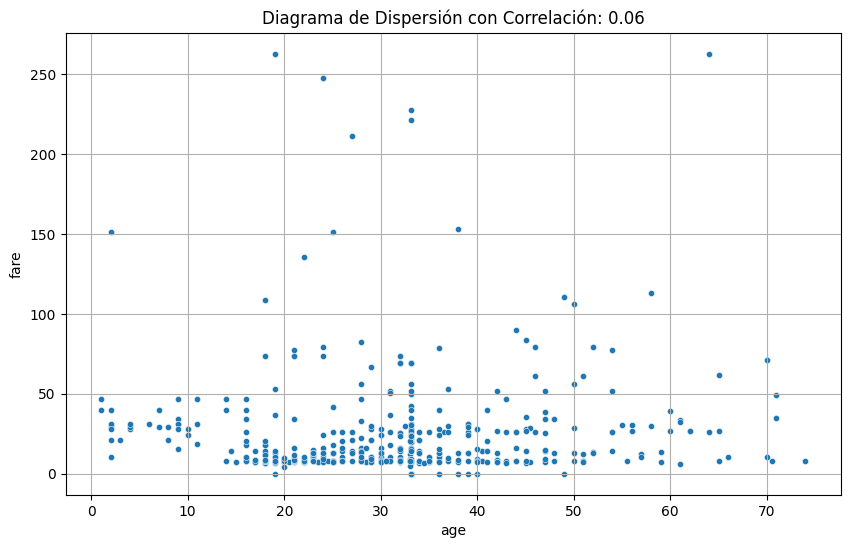

Respuesta yes:


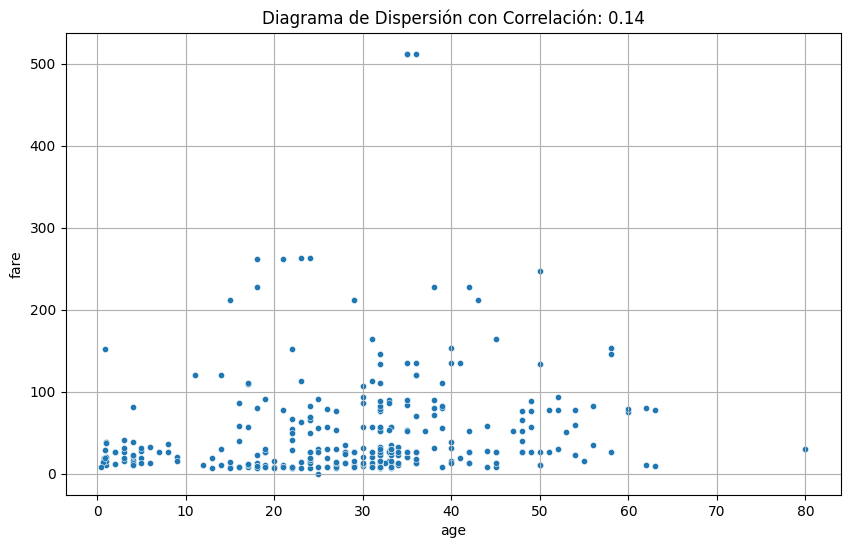

In [163]:
for valor,df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    grafico_dispersion_con_correlacion(df_datos,col_2,col_1, tamano_puntos=20, mostrar_correlacion= True)

**Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?**

Al combinar edad, coste del billete y supervivencia se observa que la tarifa —y por lo tanto la clase social— es la variable más relacionada con sobrevivir. Los pasajeros que fallecieron se concentraron casi por completo en tarifas bajas, mientras que quienes sobrevivieron pagaron billetes mucho más altos. La edad, en cambio, no muestra una correlación clara con la tarifa, pero sí se nota que entre los supervivientes hay más pasajeros jóvenes, en línea con las prioridades de evacuación (“mujeres y niños primero”). En síntesis, la supervivencia estuvo fuertemente influida por la clase social y solo de manera secundaria por la edad.

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?